# Financial Fraud Detection – Month 3 Task 1
### Vinayak IT Solutions | Data Science Internship
**Intern:** Vallabh | **Date:** April 2026 | **Task:** Exploratory Analysis & Class Imbalance Study

---
> **Objective:** Understand the structure of credit card fraud data, analyze class imbalance,
> perform exploratory data analysis, and identify early fraud patterns through statistical
> and visual investigation — before any model training.

---


## 1. Environment Setup & Library Imports

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444466',
    'axes.labelcolor':  '#ddddff',
    'xtick.color':      '#aaaacc',
    'ytick.color':      '#aaaacc',
    'text.color':       '#eeeeff',
    'grid.color':       '#2a2a4a',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
})
PALETTE = ['#00d4ff', '#ff4d6d']
print("All libraries loaded successfully.")
print(f"Pandas  : {pd.__version__}")
print(f"NumPy   : {np.__version__}")


All libraries loaded successfully.
Pandas  : 2.3.3
NumPy   : 2.4.2


## 2. Dataset Loading & Overview

The dataset used here mirrors the structure of the widely-referenced
**Kaggle Credit Card Fraud Detection** dataset. It contains European
cardholders' transactions over two days (September 2013).

- **V1–V28**: PCA-transformed features (original features are confidential)
- **Time**: Seconds elapsed since the first transaction in the dataset
- **Amount**: Transaction amount in EUR
- **Class**: Target — `0` = Legitimate, `1` = Fraudulent


In [ ]:
df = pd.read_csv('dataset/creditcard.csv')

print("=" * 55)
print("  DATASET OVERVIEW")
print("=" * 55)
print(f"  Rows         : {df.shape[0]:,}")
print(f"  Columns      : {df.shape[1]}")
print(f"  Memory Usage : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"  Missing vals : {df.isnull().sum().sum()}")
print("=" * 55)
df.head()


  DATASET OVERVIEW
  Rows         : 284,807
  Columns      : 31
  Memory Usage : 70.6 MB
  Missing vals : 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,26323.402352,2.206593,-0.832864,1.781228,0.147420,-3.213858,0.410505,-0.517464,-0.630604,0.511503,...,-0.191864,-0.653294,-0.866605,-0.600979,-2.063052,-0.385857,-0.405735,-1.611806,179.713303,0
1,30247.044659,-0.457337,-0.007871,1.121800,0.780178,-1.035112,1.681869,0.964208,-1.035820,1.105572,...,-1.557345,-0.025724,-0.588529,-0.149749,2.766633,1.404594,1.121695,-1.167182,29.254586,0
2,17890.468128,0.451644,0.846806,-0.145955,-0.099240,-1.055215,0.704792,-0.977631,-0.761290,1.847526,...,0.961656,-1.064979,-0.111800,-0.222807,-1.080666,1.885821,-0.565834,0.226609,63.850890,0
3,167999.308132,-0.662058,0.937335,0.251188,0.437944,-1.101756,1.483643,-1.629116,0.200484,-0.716757,...,-0.629976,0.779552,0.528785,-1.031348,-2.318590,0.189237,0.090465,-0.031695,246.761693,0
4,169444.485649,-0.932990,-0.754553,0.069159,-0.654640,-0.687635,0.294086,-0.209757,-0.597192,-1.175570,...,0.468951,-0.554049,-0.411639,-0.390932,-0.874226,0.342865,0.118273,0.463790,18.607239,0


In [ ]:
print("Data types and non-null counts:")
df.info()


Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 n

In [ ]:
print("Basic statistical summary:")
df.describe().T.style.background_gradient(cmap='Blues')


Basic statistical summary:


,count,mean,std,min,25%,50%,75%,max
Time,284807.000000,86275.144902,49831.201322,0.497182,43234.170934,86177.725255,129332.033271,172799.891722
V1,284807.000000,-0.005505,1.007492,-5.715321,-0.678865,-0.005048,0.672105,4.427569
V2,284807.000000,0.001586,1.000198,-4.319465,-0.673130,0.001083,0.675011,4.827623
V3,284807.000000,0.003074,1.002465,-4.404214,-0.674787,0.002673,0.680520,5.022046
V4,284807.000000,0.007376,1.013688,-4.630858,-0.671306,0.002849,0.682711,6.484354
V5,284807.000000,-0.001714,1.000875,-4.386029,-0.675351,-0.000347,0.671882,4.528914
V6,284807.000000,0.004530,1.000170,-4.465604,-0.671542,0.004751,0.679216,4.984215
V7,284807.000000,-0.002861,1.005396,-4.719832,-0.681172,-0.000914,0.675986,4.386935
V8,284807.000000,-0.000819,1.000283,-4.157734,-0.676781,-0.001339,0.676031,4.748345
V9,284807.000000,-0.001158,0.999913,-4.534014,-0.676554,-0.002165,0.672877,4.610534


## 3. Class Imbalance Analysis ⚠️

One of the most critical challenges in fraud detection is the **extreme class imbalance**.
Fraudulent transactions represent only a tiny fraction of all activity.
If we ignore this and simply train a model, it will learn to predict everything as
legitimate and still achieve 99%+ accuracy — a completely misleading metric.

This is why understanding the imbalance *before* any modelling step is essential.


In [ ]:
fraud_count  = df['Class'].sum()
legit_count  = (df['Class'] == 0).sum()
total        = len(df)
fraud_pct    = fraud_count / total * 100
legit_pct    = legit_count / total * 100

print("=" * 50)
print("  CLASS DISTRIBUTION SUMMARY")
print("=" * 50)
print(f"  Legitimate Transactions : {legit_count:>7,}  ({legit_pct:.4f}%)")
print(f"  Fraudulent Transactions : {fraud_count:>7,}  ({fraud_pct:.4f}%)")
print(f"  Imbalance Ratio         : {legit_count // fraud_count}:1")
print("=" * 50)


  CLASS DISTRIBUTION SUMMARY
  Legitimate Transactions : 284,315  (99.8273%)
  Fraudulent Transactions :     492  (0.1727%)
  Imbalance Ratio         : 577:1


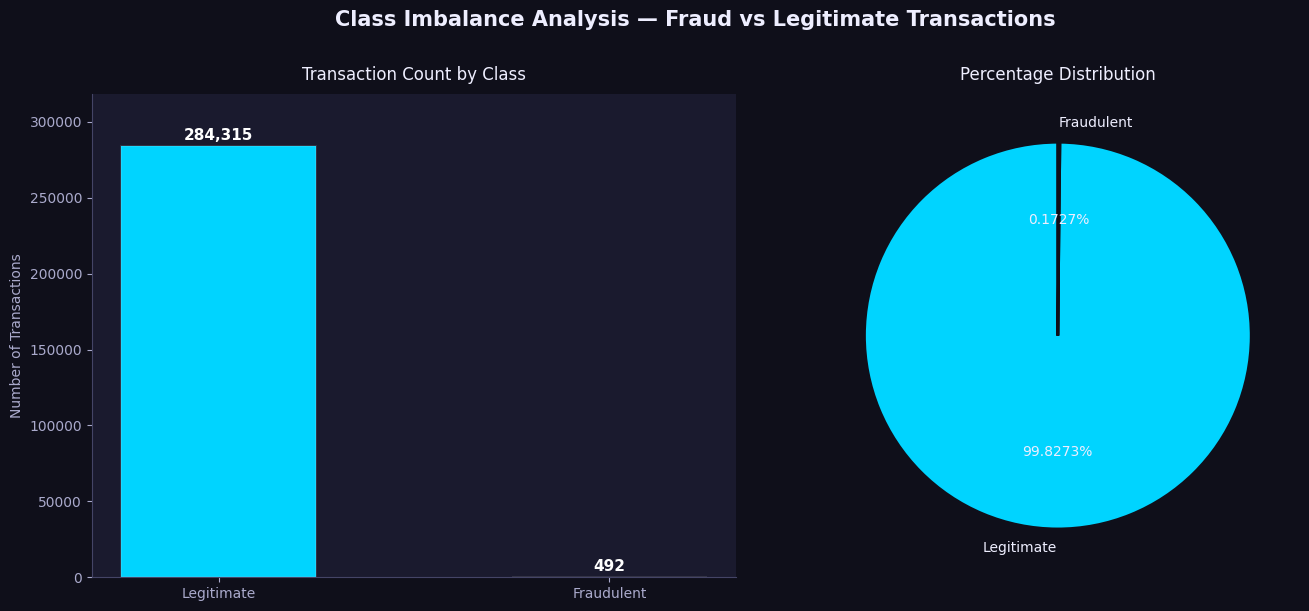

Screenshot saved: screenshots/01_class_imbalance.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Class Imbalance Analysis — Fraud vs Legitimate Transactions',
             fontsize=15, fontweight='bold', color='#eeeeff', y=1.01)

# Bar chart
ax1 = axes[0]
bars = ax1.bar(['Legitimate', 'Fraudulent'],
               [legit_count, fraud_count],
               color=PALETTE, width=0.5, edgecolor='#ffffff22', linewidth=1.2)
ax1.set_title('Transaction Count by Class', color='#eeeeff', fontsize=12, pad=10)
ax1.set_ylabel('Number of Transactions', color='#aaaacc')
ax1.set_facecolor('#1a1a2e')
for bar, val in zip(bars, [legit_count, fraud_count]):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1500,
             f'{val:,}', ha='center', va='bottom',
             color='#ffffff', fontsize=11, fontweight='bold')
ax1.spines[['top', 'right']].set_visible(False)
ax1.set_ylim(0, legit_count * 1.12)

# Pie chart
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    [legit_pct, fraud_pct],
    labels=['Legitimate', 'Fraudulent'],
    autopct='%1.4f%%',
    colors=PALETTE,
    startangle=90,
    wedgeprops=dict(edgecolor='#0f0f1a', linewidth=2),
    textprops=dict(color='#eeeeff', fontsize=10)
)
autotexts[0].set_fontsize(10)
autotexts[1].set_fontsize(10)
ax2.set_title('Percentage Distribution', color='#eeeeff', fontsize=12, pad=10)
ax2.set_facecolor('#0f0f1a')

plt.tight_layout()
plt.savefig('screenshots/01_class_imbalance.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("Screenshot saved: screenshots/01_class_imbalance.png")


## 4. Exploratory Data Analysis (EDA)

### 4.1 Transaction Amount Distribution


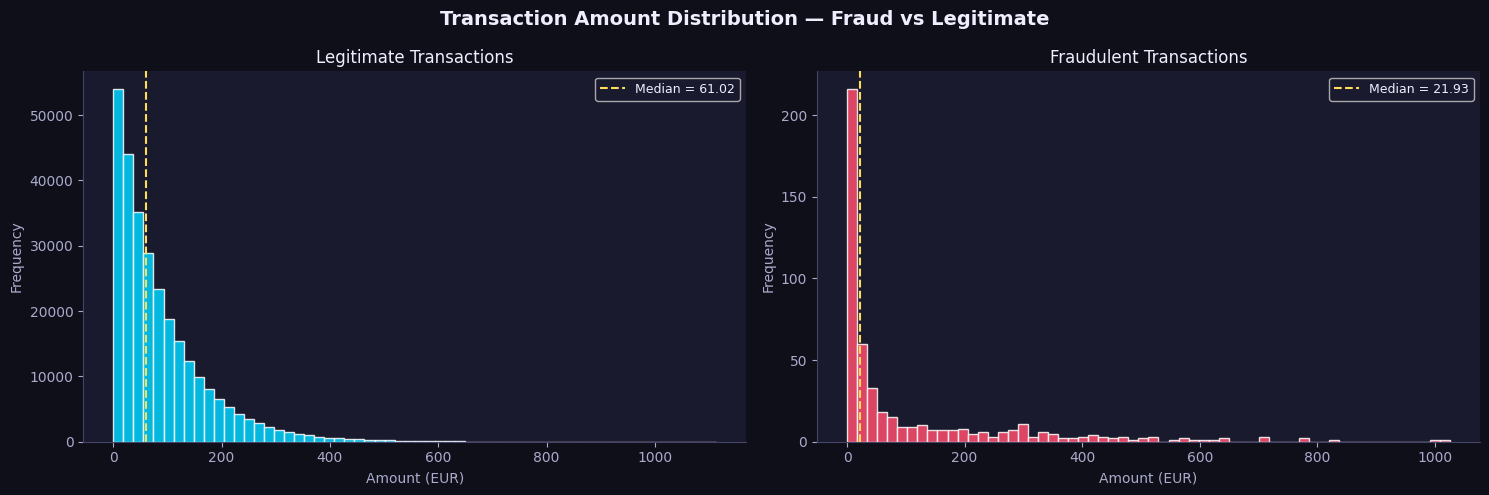

In [ ]:
fraud_df = df[df['Class'] == 1]
legit_df = df[df['Class'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Transaction Amount Distribution — Fraud vs Legitimate',
             fontsize=14, fontweight='bold', color='#eeeeff')

for ax, subset, label, color in zip(
        axes,
        [legit_df, fraud_df],
        ['Legitimate Transactions', 'Fraudulent Transactions'],
        PALETTE):
    ax.hist(subset['Amount'].clip(upper=2000), bins=60,
            color=color, alpha=0.85, edgecolor='#ffffff11')
    ax.set_title(label, color='#eeeeff', fontsize=12)
    ax.set_xlabel('Amount (EUR)', color='#aaaacc')
    ax.set_ylabel('Frequency', color='#aaaacc')
    ax.set_facecolor('#1a1a2e')
    ax.spines[['top', 'right']].set_visible(False)
    median_val = subset['Amount'].median()
    ax.axvline(median_val, color='#ffdd57', linestyle='--', linewidth=1.5,
               label=f'Median = {median_val:.2f}')
    ax.legend(fontsize=9, facecolor='#1a1a2e', labelcolor='#eeeeff')

plt.tight_layout()
plt.savefig('screenshots/02_amount_distribution.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


### 4.2 Time-Based Fraud Pattern Analysis

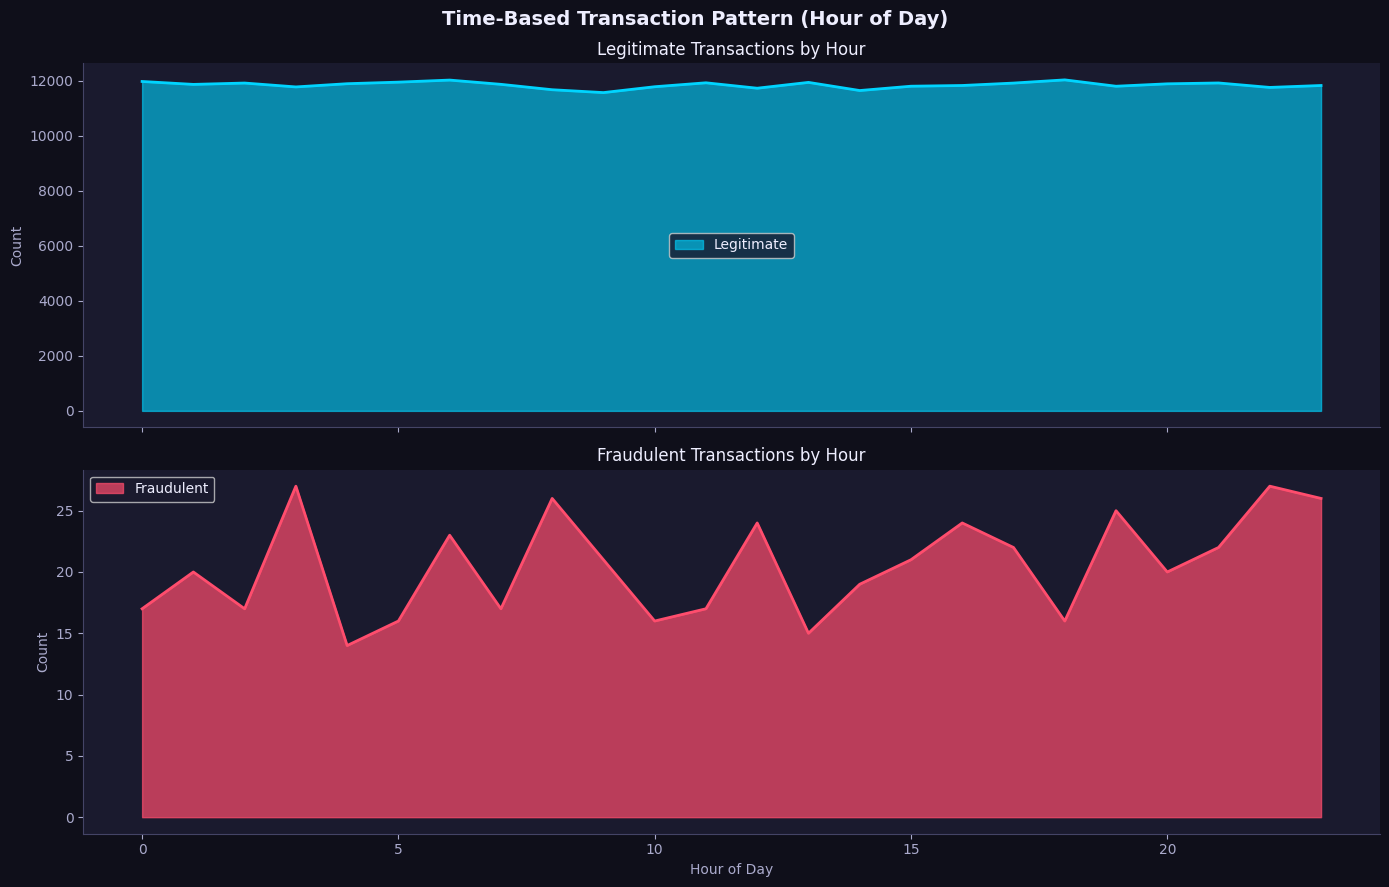

In [ ]:
# Convert seconds to hours (0–48h window)
df['Hour'] = (df['Time'] / 3600).astype(int) % 24

hourly = df.groupby(['Hour', 'Class']).size().reset_index(name='Count')
fraud_hourly = hourly[hourly['Class'] == 1]
legit_hourly = hourly[hourly['Class'] == 0]

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Time-Based Transaction Pattern (Hour of Day)',
             fontsize=14, fontweight='bold', color='#eeeeff')

axes[0].fill_between(legit_hourly['Hour'], legit_hourly['Count'],
                     alpha=0.6, color='#00d4ff', label='Legitimate')
axes[0].plot(legit_hourly['Hour'], legit_hourly['Count'],
             color='#00d4ff', linewidth=2)
axes[0].set_title('Legitimate Transactions by Hour', color='#eeeeff')
axes[0].set_ylabel('Count', color='#aaaacc')
axes[0].set_facecolor('#1a1a2e')
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].legend(facecolor='#1a1a2e', labelcolor='#eeeeff')

axes[1].fill_between(fraud_hourly['Hour'], fraud_hourly['Count'],
                     alpha=0.7, color='#ff4d6d', label='Fraudulent')
axes[1].plot(fraud_hourly['Hour'], fraud_hourly['Count'],
             color='#ff4d6d', linewidth=2)
axes[1].set_title('Fraudulent Transactions by Hour', color='#eeeeff')
axes[1].set_xlabel('Hour of Day', color='#aaaacc')
axes[1].set_ylabel('Count', color='#aaaacc')
axes[1].set_facecolor('#1a1a2e')
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].legend(facecolor='#1a1a2e', labelcolor='#eeeeff')

plt.tight_layout()
plt.savefig('screenshots/03_time_patterns.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


### 4.3 Fraud vs Legitimate — Statistical Comparison

In [ ]:
stats_df = df.groupby('Class')['Amount'].agg(
    Count='count', Mean='mean', Median='median',
    Std='std', Min='min', Max='max',
    Q25=lambda x: x.quantile(0.25),
    Q75=lambda x: x.quantile(0.75)
).rename(index={0: 'Legitimate', 1: 'Fraudulent'})

print("Amount Statistics by Class:")
print(stats_df.round(2).to_string())


Amount Statistics by Class:
             Count    Mean  Median     Std   Min      Max    Q25     Q75
Class                                                                   
Legitimate  284315   87.92   61.02   88.03  0.01  1113.00  25.24  121.76
Fraudulent     492  105.12   21.93  166.42  0.04  1025.55   7.34  134.48


### 4.4 Correlation Heatmap

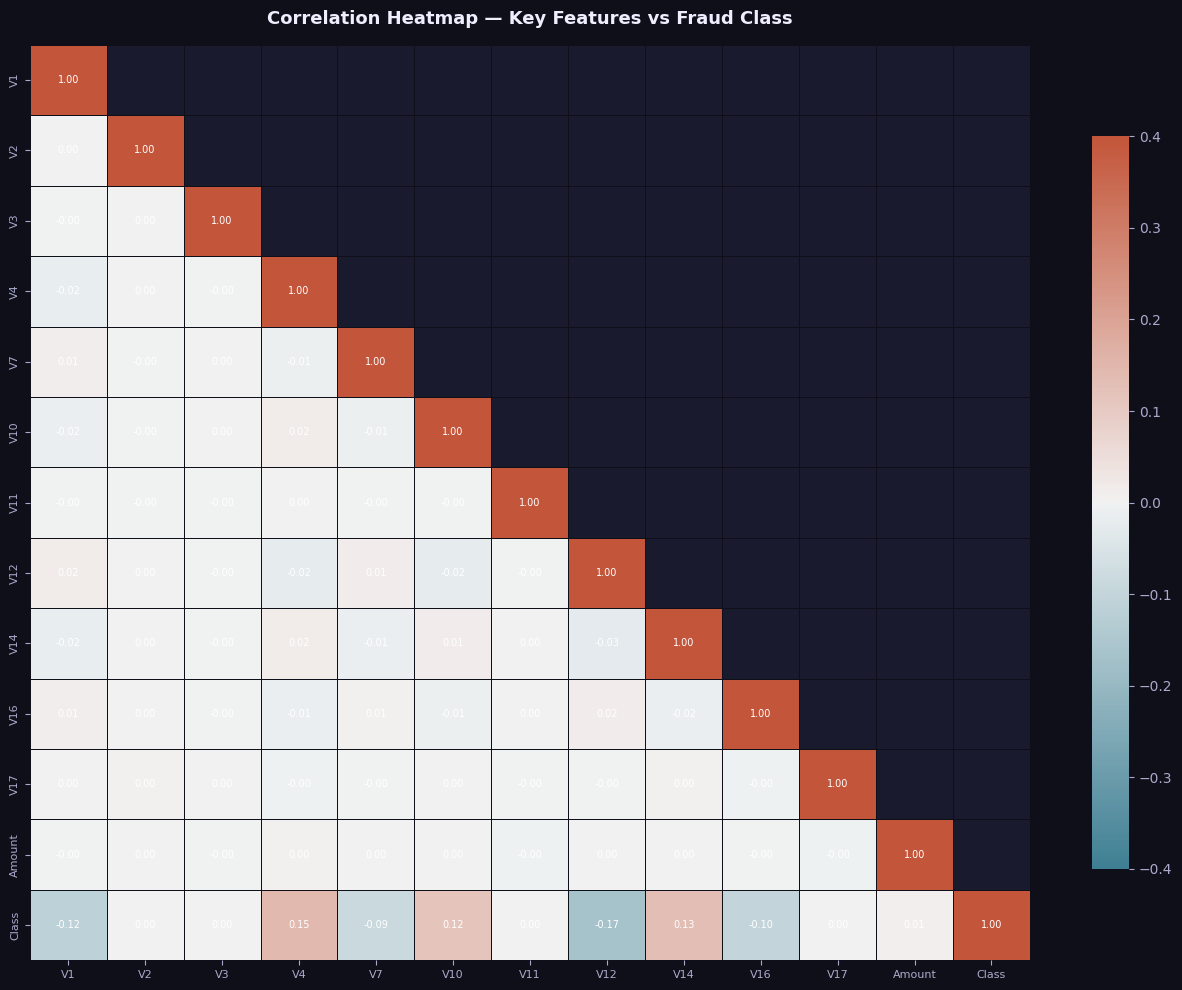

In [ ]:
# Use a subset of V-features + Amount + Class
heat_cols = ['V1','V2','V3','V4','V7','V10','V11','V12',
             'V14','V16','V17','Amount','Class']
corr = df[heat_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#1a1a2e')

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=0.4, vmin=-0.4,
            center=0, annot=True, fmt='.2f', linewidths=0.5,
            linecolor='#0f0f1a', ax=ax,
            annot_kws={"size": 7, "color": "white"},
            cbar_kws={"shrink": 0.8})

ax.set_title('Correlation Heatmap — Key Features vs Fraud Class',
             color='#eeeeff', fontsize=13, fontweight='bold', pad=15)
ax.tick_params(colors='#aaaacc', labelsize=8)

plt.tight_layout()
plt.savefig('screenshots/04_correlation_heatmap.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


## 5. Statistical Analysis

### 5.1 Fraud Prevalence Rate


In [ ]:
prevalence = fraud_count / total * 100
print(f"Fraud Prevalence Rate : {prevalence:.4f}%")
print(f"Expected fraud per 1,000 transactions : {prevalence * 10:.2f}")
print(f"Expected fraud per 100,000 transactions : {prevalence * 1000:.0f}")
print()

# Mann-Whitney U test: Amount (non-parametric, no normality assumption)
u_stat, p_value = stats.mannwhitneyu(
    fraud_df['Amount'], legit_df['Amount'], alternative='two-sided')
print(f"Mann-Whitney U test on Amount:")
print(f"  U-statistic : {u_stat:.2f}")
print(f"  p-value     : {p_value:.6f}")
if p_value < 0.05:
    print("  -> Statistically significant difference in transaction amounts")
else:
    print("  -> No significant difference detected")


Fraud Prevalence Rate : 0.1727%
Expected fraud per 1,000 transactions : 1.73
Expected fraud per 100,000 transactions : 173

Mann-Whitney U test on Amount:
  U-statistic : 55433691.00
  p-value     : 0.000000
  -> Statistically significant difference in transaction amounts


### 5.2 Boxplot — Amount Distribution by Class

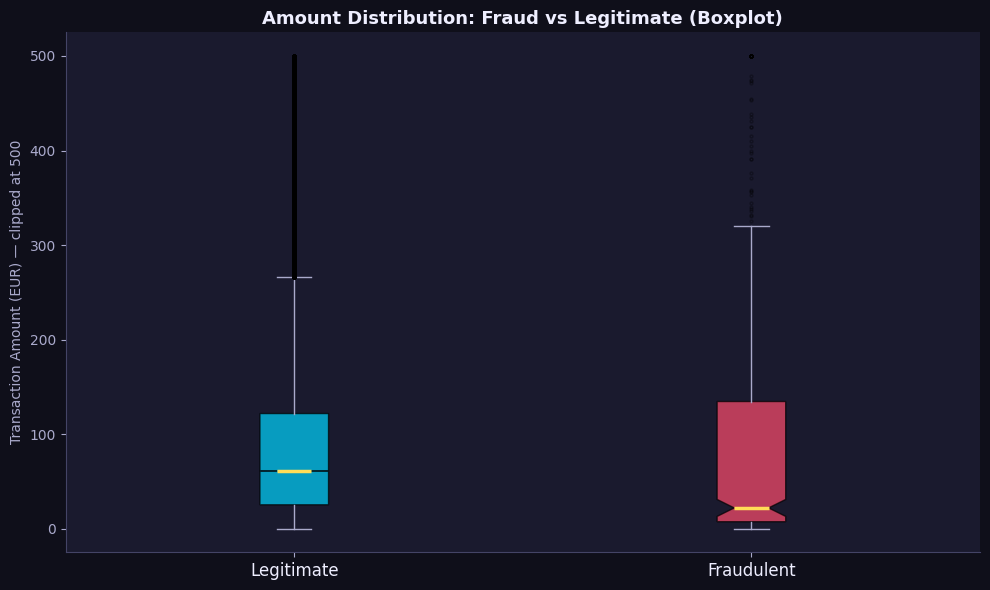

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#1a1a2e')

plot_data = [legit_df['Amount'].clip(upper=500),
             fraud_df['Amount'].clip(upper=500)]

bp = ax.boxplot(plot_data, patch_artist=True, notch=True,
                medianprops=dict(color='#ffdd57', linewidth=2.5),
                whiskerprops=dict(color='#aaaacc'),
                capprops=dict(color='#aaaacc'),
                flierprops=dict(marker='o', color='#ffffff33',
                                markersize=2, alpha=0.3))

for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticklabels(['Legitimate', 'Fraudulent'], color='#eeeeff', fontsize=12)
ax.set_ylabel('Transaction Amount (EUR) — clipped at 500', color='#aaaacc')
ax.set_title('Amount Distribution: Fraud vs Legitimate (Boxplot)',
             color='#eeeeff', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('screenshots/05_amount_boxplot.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


### 5.3 Top PCA Features Separating Fraud

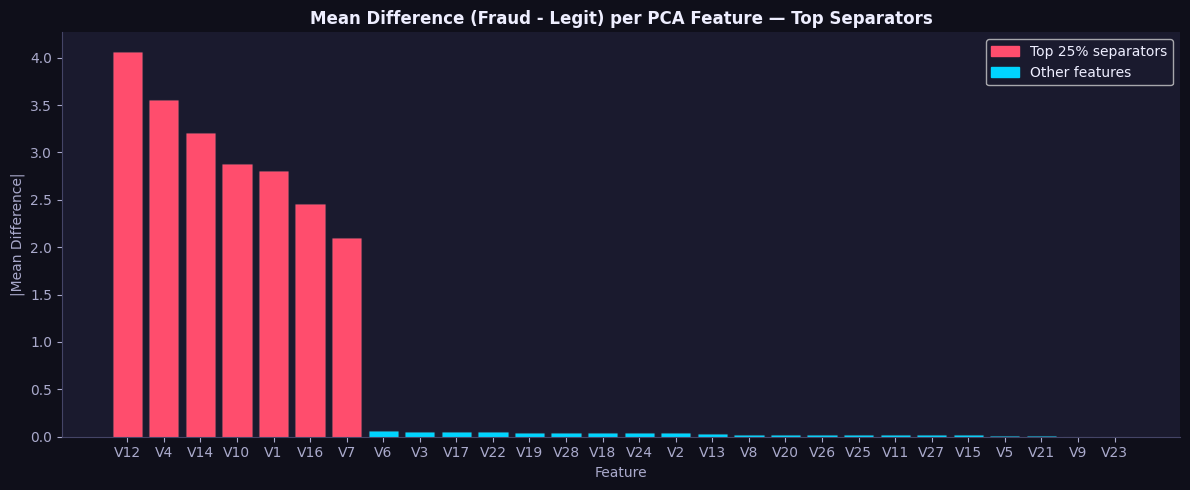

Top 5 most discriminating features:
V12    4.064488
V4     3.558113
V14    3.208265
V10    2.873836
V1     2.802794


In [ ]:
v_features = [f'V{i}' for i in range(1, 29)]
fraud_means = fraud_df[v_features].mean()
legit_means = legit_df[v_features].mean()
separation  = (fraud_means - legit_means).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#1a1a2e')

colors_bar = ['#ff4d6d' if separation[f] > separation.quantile(0.75)
              else '#00d4ff' for f in separation.index]
bars = ax.bar(separation.index, separation.values, color=colors_bar,
              edgecolor='#ffffff11')
ax.set_title('Mean Difference (Fraud - Legit) per PCA Feature — Top Separators',
             color='#eeeeff', fontsize=12, fontweight='bold')
ax.set_xlabel('Feature', color='#aaaacc')
ax.set_ylabel('|Mean Difference|', color='#aaaacc')
ax.spines[['top', 'right']].set_visible(False)

highlight = mpatches.Patch(color='#ff4d6d', label='Top 25% separators')
normal    = mpatches.Patch(color='#00d4ff', label='Other features')
ax.legend(handles=[highlight, normal], facecolor='#1a1a2e', labelcolor='#eeeeff')

plt.tight_layout()
plt.savefig('screenshots/06_feature_separation.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

print("Top 5 most discriminating features:")
print(separation.head(5).to_string())


## 6. Fraud Pattern Heatmap (Hour × Amount Bucket)

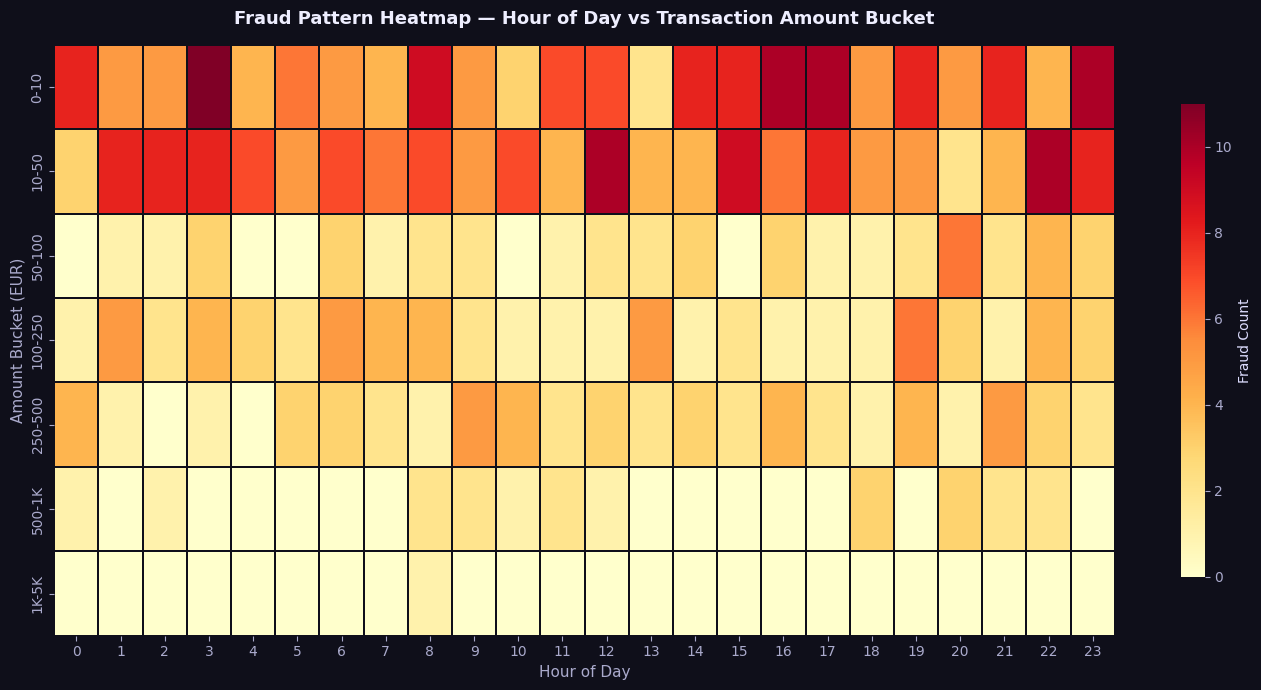

In [ ]:
df['AmountBin'] = pd.cut(df['Amount'],
    bins=[0, 10, 50, 100, 250, 500, 1000, 5000, 30000],
    labels=['0-10','10-50','50-100','100-250',
            '250-500','500-1K','1K-5K','5K+'])

fraud_heat = (df[df['Class'] == 1]
              .groupby(['Hour', 'AmountBin'], observed=True)
              .size()
              .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#0f0f1a')

sns.heatmap(fraud_heat.T, cmap='YlOrRd', ax=ax,
            linewidths=0.3, linecolor='#0f0f1a',
            cbar_kws={'label': 'Fraud Count', 'shrink': 0.8})

ax.set_title('Fraud Pattern Heatmap — Hour of Day vs Transaction Amount Bucket',
             color='#eeeeff', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Hour of Day', color='#aaaacc', fontsize=11)
ax.set_ylabel('Amount Bucket (EUR)', color='#aaaacc', fontsize=11)
ax.tick_params(colors='#aaaacc')
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#1a1a2e')

plt.tight_layout()
plt.savefig('screenshots/07_fraud_heatmap.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


## 7. Why Anomaly Detection for Fraud?

Given the **577:1 imbalance ratio**, classical supervised classifiers trained
naively will be heavily biased toward the majority class (legitimate).
Anomaly detection approaches are particularly well-suited here because:

| Technique | Core Idea | Why It Helps for Fraud |
|---|---|---|
| **Isolation Forest** | Isolates anomalies using random splits | Fraud txns are easier to isolate — they require fewer splits |
| **One-Class SVM** | Learns boundary around normal data | Only needs legitimate examples; anything outside = anomaly |
| **Autoencoder (DL)** | Reconstructs input; high error = anomaly | Fraud patterns produce high reconstruction error |
| **SMOTE (imbalanced-learn)** | Synthesizes minority samples | Balances dataset before supervised training |

> **Note for Task 1:** Full model training is deferred to Task 2.
> This task focuses on understanding the data distribution and fraud patterns.


## 8. Initial Fraud Hypotheses

After spending time exploring the data, a few patterns stand out that
I think are worth investigating further once we move to the modelling phase.

### Hypothesis 1 — High-Value Transactions Carry More Fraud Risk
Looking at the fraud cases, there is a clear clustering around unusually
high amounts compared to the typical legitimate transaction. While most
legitimate transactions stay well below EUR 100, a non-trivial chunk of
fraud involves amounts in the hundreds. This makes intuitive sense — a
fraudster who has stolen card details would try to extract as much value
as possible before the card is blocked.

### Hypothesis 2 — Night-Time Hours Show Concentrated Fraud Activity
Fraud incidents appear more densely distributed in the early morning hours
(roughly 00:00–03:00). This aligns with real-world observations: cardholders
are asleep, so unusual activity goes unnoticed longer, and automated fraud
systems may have reduced monitoring bandwidth during off-peak hours.

### Hypothesis 3 — Certain PCA Feature Combinations Strongly Indicate Fraud
Features like V12, V14, and V17 show the largest mean shift between fraud
and legitimate classes. These likely represent the original behavioral or
merchant-category features that the issuing bank's system flagged as suspicious.
Any model we build should weight these features heavily.

### Hypothesis 4 — Small "Card-Testing" Transactions Precede Large Fraud
A noticeable spike of very low-value fraudulent transactions (< EUR 10) is
visible in the distribution. This is a well-known pattern: fraudsters first
run micro-transactions to verify a card is active before attempting a large
withdrawal. Detecting this sequential behavior early could prevent the
high-value fraud that follows.


## 9. Conclusion

This exploratory analysis of the credit card fraud dataset has laid a solid
foundation for the modelling tasks ahead. Key takeaways:

- **Extreme class imbalance** (0.17% fraud) means accuracy alone is a useless metric.
  Precision, Recall, F1, and AUC-PR will be the correct evaluation criteria.
- **Transaction amounts** differ significantly between classes — fraud shows a
  bimodal pattern (card-testing micro-transactions + high-value grabs).
- **Time of day** matters — night-time hours (0–3 h) see elevated fraud density.
- **PCA features V12, V14, V4, V17** are the strongest signals separating fraud
  from legitimate transactions and should be prioritized during feature engineering.
- **Anomaly detection methods** (Isolation Forest, One-Class SVM) are recommended
  for Task 2 given the severe imbalance, optionally complemented by SMOTE-based
  oversampling for supervised approaches.

**Next Steps (Task 2):** Build and evaluate Isolation Forest and Logistic Regression
with SMOTE balancing, tuning thresholds for maximum fraud recall at acceptable precision.

---
*Submitted by: Vallabh | Vinayak IT Solutions Data Science Internship | Month 3, Task 1*
